# Differentiating Through Solve

Because gaussx primitives are pure JAX functions built on lineax
and equinox, they are fully differentiable. This notebook shows
how to use `jax.grad` and `jax.jacobian` through `gaussx.solve`
for inverse problems and sensitivity analysis.

## Mathematical background: implicit differentiation

When a linear system $A(\theta)\, x(\theta) = b$ defines the
solution $x$ implicitly as a function of parameters $\theta$,
differentiating both sides with respect to $\theta$ gives

$$\frac{\partial x}{\partial \theta}
= -A^{-1} \frac{\partial A}{\partial \theta}\, x$$

This is the implicit function theorem applied to the linear case.
Computing $\partial x / \partial \theta$ requires one additional
linear solve (with the same matrix $A$), but never requires forming
or storing the full Jacobian $\partial x / \partial \theta$ explicitly.

## How lineax computes gradients under the hood

gaussx delegates all linear solves to
[lineax](https://github.com/patrick-kidger/lineax), which registers
custom **JVP** (forward-mode) and **VJP** (reverse-mode / adjoint)
rules with JAX for its `linear_solve` primitive. This is what makes
`jax.grad` "just work" through `gaussx.solve`.

### Forward mode (JVP)

Given primals $(A, b)$ and tangents $(\dot{A}, \dot{b})$, lineax
computes the tangent of the solution $\dot{x}$ by solving a single
linear system with the **same** operator $A$:

$$\dot{x} = A^{-1}\bigl(\dot{b} - \dot{A}\, x\bigr)$$

This follows from differentiating $A x = b$ in the forward direction:
$\dot{A}\,x + A\,\dot{x} = \dot{b}$, rearranged. In lineax's
implementation, $\dot{A}\,x$ is computed via a `TangentLinearOperator`
that wraps the primal and tangent operators together, using JAX's own
`jvp` to differentiate the matvec. This means lineax never needs to
form $\dot{A}$ as a dense matrix — it only needs the action
$\dot{A}\,v$ for specific vectors $v$.

More generally, lineax implements the full **Moore--Penrose
pseudoinverse derivative** (Golub & Pereyra, 1973), which handles
singular, overdetermined, and underdetermined systems uniformly.
For the common case of a full-rank square system, this simplifies to
the formula above.

### Reverse mode (VJP / adjoint method)

Reverse-mode AD is what `jax.grad` uses. Given a scalar loss
$\ell(x)$ where $x = A^{-1} b$, the backward pass needs to propagate
the cotangent $\bar{x} = \partial \ell / \partial x$ back to
cotangents for $A$ and $b$.

Lineax implements this by solving an **adjoint system** with the
transposed operator:

$$\lambda = A^{-\top} \bar{x}$$

The cotangent with respect to $b$ is then $\bar{b} = \lambda$, and
the cotangent with respect to $A$ (as a linear map acting on
perturbations $\delta A$) is
$\bar{A} : \delta A \mapsto -\lambda^\top (\delta A)\, x$.

Crucially, lineax **reuses the solver's factorization** for the
adjoint solve. For direct solvers (Cholesky, LU), the `transpose()`
method flips a flag on the existing factorization rather than
recomputing it. For Cholesky ($A = LL^\top$, so $A^\top = A$), the
adjoint solve is essentially free. For iterative solvers (CG), the
transposed system is solved with the same algorithm since PSD
operators are self-adjoint.

### Why this matters in practice

| Mode | Cost | Best when |
|------|------|-----------|
| Forward (JVP) | 1 extra solve per tangent direction | Few parameters, many outputs |
| Reverse (VJP) | 1 adjoint solve total | Many parameters, scalar loss |

For GP hyperparameter optimization, reverse mode is almost always
preferred: the loss is scalar (negative log-marginal likelihood) but
there may be many hyperparameters. `jax.grad` uses reverse mode by
default, so a single call through `gaussx.solve` triggers exactly
**two** linear solves — one forward, one adjoint — regardless of
the number of hyperparameters.

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## 1. Gradient of a loss through solve

Consider optimizing a parameter $\theta$ that appears in the
matrix $A(\theta)$. We want $\nabla_\theta \|A(\theta)^{-1} b - x^*\|^2$.

In [2]:
def build_op(theta):
    """Build a PSD matrix parameterized by theta."""
    # Diagonal + scaled off-diagonal coupling
    diag = jnp.array([1.0, 2.0, 3.0]) + theta
    off = theta * 0.1
    mat = jnp.diag(diag) + off * (jnp.ones((3, 3)) - jnp.eye(3))
    return lx.MatrixLinearOperator(mat, lx.positive_semidefinite_tag)


b = jnp.array([1.0, 2.0, 3.0])
x_target = jnp.array([0.5, 0.5, 0.5])


def loss(theta):
    op = build_op(theta)
    x = gaussx.solve(op, b)
    return jnp.sum((x - x_target) ** 2)


theta = 1.0
print(f"loss(theta={theta}): {loss(theta):.6f}")

grad_loss = jax.grad(loss)
print(f"grad(theta={theta}): {grad_loss(theta):.6f}")

# Verify with finite differences
eps = 1e-5
fd_grad = (loss(theta + eps) - loss(theta - eps)) / (2 * eps)
print(f"finite diff grad:    {fd_grad:.6f}")
print(f"match: {jnp.allclose(grad_loss(theta), fd_grad, rtol=1e-4)}")

loss(theta=1.0): 0.070932


grad(theta=1.0): -0.111321
finite diff grad:    -0.111321
match: True


## 2. Gradient sweep over theta

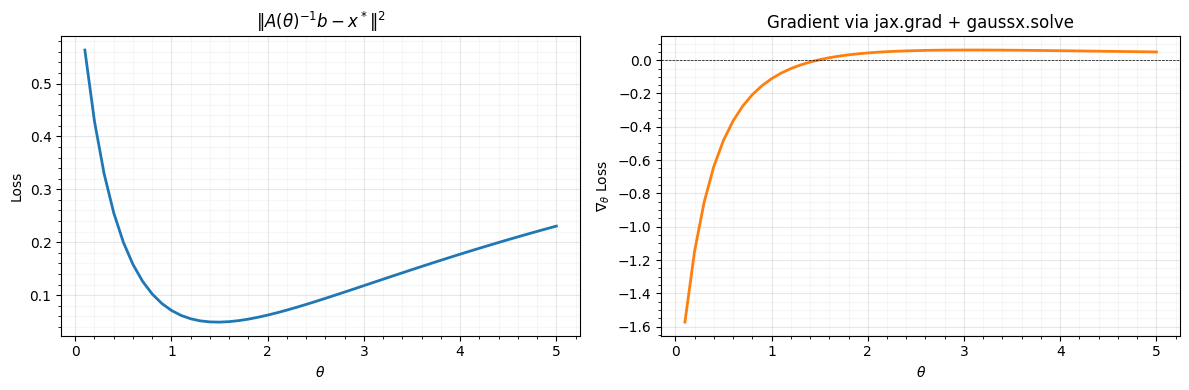

In [3]:
thetas = jnp.linspace(0.1, 5.0, 50)
losses = jax.vmap(loss)(thetas)
grads = jax.vmap(grad_loss)(thetas)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(thetas, losses, "C0-", lw=2)
axes[0].set_xlabel("$\\theta$")
axes[0].set_ylabel("Loss")
axes[0].set_title("$\\|A(\\theta)^{-1}b - x^*\\|^2$")
axes[0].grid(True, which="major", alpha=0.3)
axes[0].grid(True, which="minor", alpha=0.1)
axes[0].minorticks_on()

axes[1].plot(thetas, grads, "C1-", lw=2)
axes[1].axhline(0, color="k", lw=0.5, ls="--")
axes[1].set_xlabel("$\\theta$")
axes[1].set_ylabel("$\\nabla_\\theta$ Loss")
axes[1].set_title("Gradient via jax.grad + gaussx.solve")
axes[1].grid(True, which="major", alpha=0.3)
axes[1].grid(True, which="minor", alpha=0.1)
axes[1].minorticks_on()

plt.tight_layout()
plt.show()

## 3. Gradient descent to find optimal theta

In [4]:
theta = 3.0  # starting point
lr = 0.5
trajectory = [theta]

for _i in range(30):
    g = grad_loss(theta)
    theta = theta - lr * g
    trajectory.append(float(theta))

trajectory = jnp.array(trajectory)
print(f"Optimal theta: {trajectory[-1]:.4f}")
print(f"Final loss: {loss(trajectory[-1]):.8f}")

Optimal theta: 2.1412
Final loss: 0.06871058


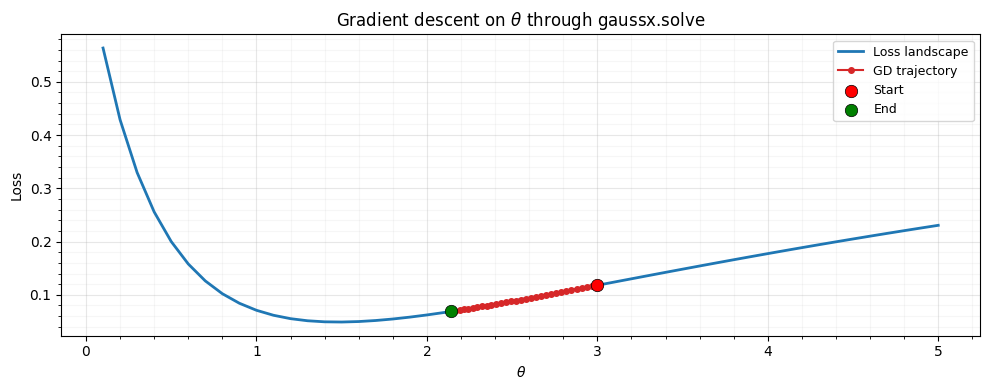

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thetas, losses, "C0-", lw=2, label="Loss landscape")
ax.plot(
    trajectory,
    jax.vmap(loss)(trajectory),
    "C3o-",
    ms=4,
    zorder=3,
    label="GD trajectory",
)
ax.scatter(
    trajectory[0],
    loss(trajectory[0]),
    s=80,
    c="red",
    edgecolors="k",
    linewidths=0.5,
    zorder=5,
    label="Start",
)
ax.scatter(
    trajectory[-1],
    loss(trajectory[-1]),
    s=80,
    c="green",
    edgecolors="k",
    linewidths=0.5,
    zorder=5,
    label="End",
)
ax.set_xlabel("$\\theta$")
ax.set_ylabel("Loss")
ax.set_title("Gradient descent on $\\theta$ through gaussx.solve")
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## 4. Differentiating logdet

The derivative of the log-determinant with respect to a parameter
$\theta$ is given by Jacobi's formula:

$$\frac{\partial}{\partial \theta} \log|A(\theta)|
= \operatorname{tr}\!\bigl(A(\theta)^{-1}
\frac{\partial A}{\partial \theta}\bigr)$$

This identity is central to many applications. In GP inference, it
appears in the gradient of the log-marginal likelihood, where the
complexity penalty term involves $\log|K + \sigma^2 I|$ and its
derivative with respect to kernel hyperparameters.

gaussx + JAX computes this automatically via reverse-mode AD.

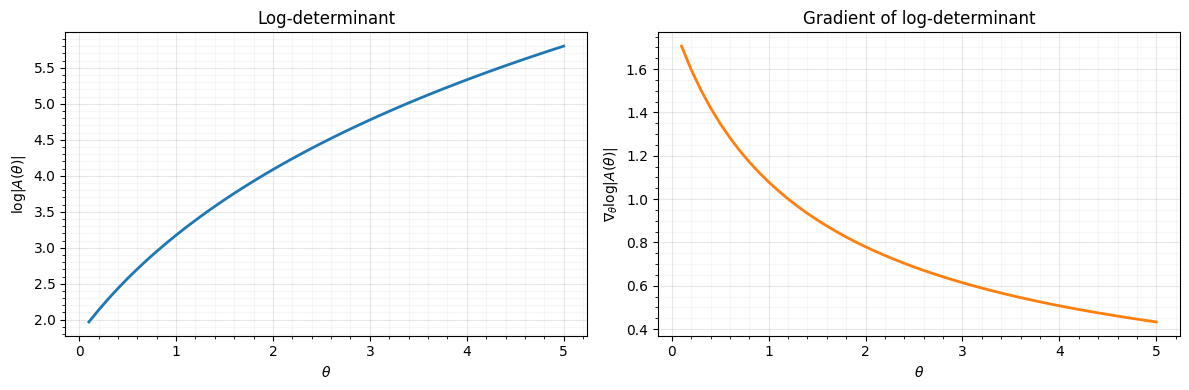

In [6]:
def logdet_of_theta(theta):
    op = build_op(theta)
    return gaussx.logdet(op)


grad_logdet = jax.grad(logdet_of_theta)

logdets = jax.vmap(logdet_of_theta)(thetas)
grad_logdets = jax.vmap(grad_logdet)(thetas)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(thetas, logdets, "C0-", lw=2)
axes[0].set_xlabel("$\\theta$")
axes[0].set_ylabel("$\\log|A(\\theta)|$")
axes[0].set_title("Log-determinant")
axes[0].grid(True, which="major", alpha=0.3)
axes[0].grid(True, which="minor", alpha=0.1)
axes[0].minorticks_on()

axes[1].plot(thetas, grad_logdets, "C1-", lw=2)
axes[1].set_xlabel("$\\theta$")
axes[1].set_ylabel("$\\nabla_\\theta \\log|A(\\theta)|$")
axes[1].set_title("Gradient of log-determinant")
axes[1].grid(True, which="major", alpha=0.3)
axes[1].grid(True, which="minor", alpha=0.1)
axes[1].minorticks_on()

plt.tight_layout()
plt.show()

## Connection to GP inference

Both the solve and logdet gradients appear together in the gradient
of the GP log-marginal likelihood:

$$\log p(y|X,\theta) = -\tfrac{1}{2} y^\top K_y^{-1} y
- \tfrac{1}{2} \log|K_y| - \tfrac{n}{2} \log 2\pi$$

Differentiating with respect to hyperparameters requires
$\partial(K_y^{-1} y)/\partial\theta$ (a solve gradient) and
$\partial \log|K_y|/\partial\theta$ (a logdet gradient). gaussx + JAX
computes both simultaneously via reverse-mode AD through a single
evaluation of the log-marginal likelihood. This is more efficient than
implementing the analytic gradient expressions manually, and it
generalizes automatically to new kernel parameterizations without
additional derivation.

## Summary

| What | How |
|------|-----|
| grad of solve | `jax.grad(lambda t: f(gaussx.solve(A(t), b)))` |
| $\nabla_\theta \log|A(\theta)|$ | `jax.grad(lambda t: gaussx.logdet(A(t)))` |
| Jacobian | `jax.jacobian(lambda t: gaussx.solve(A(t), b))` |
| Batched gradients | `jax.vmap(jax.grad(loss))` |

All gaussx primitives support arbitrary-order differentiation
because they are built on lineax (which provides custom JVP rules
for `linear_solve`) and standard JAX operations.

## References

- Golub, G. H. & Pereyra, V. (1973). The differentiation of
  pseudo-inverses and nonlinear least squares problems whose
  variables separate. *SIAM J. Numerical Analysis*, 10(2), 413-432.
- Griewank, A. & Walther, A. (2008). *Evaluating Derivatives:
  Principles and Techniques of Algorithmic Differentiation*.
  2nd edition, SIAM.
- Kidger, P. (2024). lineax: structured linear solves and linear
  least-squares in JAX. https://github.com/patrick-kidger/lineax
- Petersen, K. B. & Pedersen, M. S. (2012). *The Matrix Cookbook*.
  Technical University of Denmark.
- Rasmussen, C. E. & Williams, C. K. I. (2006). *Gaussian Processes
  for Machine Learning*. MIT Press.